In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
 
PROJECT_ROOT = Path("../..").resolve()
 
DATA_DIR = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / "hi" / "kdr"
FIG_DIR = DATA_DIR / "figures_feature_explainability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
 
PROTOCOL_COLORS = {"OOD holdout": "#2563EB", "Random shuffle": "#DC2626"}
PROTOCOL_ORDER = ["OOD holdout", "Random shuffle"]
 
fi_all = pd.read_csv(DATA_DIR / "feature_importance_all.csv")
fi_topk = pd.read_csv(DATA_DIR / "feature_topk.csv")
overlap_protocol = pd.read_csv(DATA_DIR / "feature_overlap_protocol.csv")
stability = pd.read_csv(DATA_DIR / "feature_stability_intra_protocol.csv")
fi_summary = pd.read_csv(DATA_DIR / "feature_importance_summary.csv")
local_candidates = pd.read_csv(DATA_DIR / "local_molecule_candidates.csv")
local_contributions = pd.read_csv(DATA_DIR / "local_feature_contributions.csv")
 
MODELS = fi_all["model"].unique()
FINGERPRINTS = fi_all["fingerprint"].unique()
 
print(f"Loaded: {len(fi_all)} feature importance rows")
print(f"Models: {list(MODELS)}")
print(f"Fingerprints: {list(FINGERPRINTS)}")

Loaded: 22740 feature importance rows
Models: ['Decision Tree', 'Logistic Regression', 'SVM linear']
Fingerprints: ['ecfp4', 'maccs', 'rdkit_desc']


# Absolute importance distribution

Saved: importance_distribution_decision_tree.png


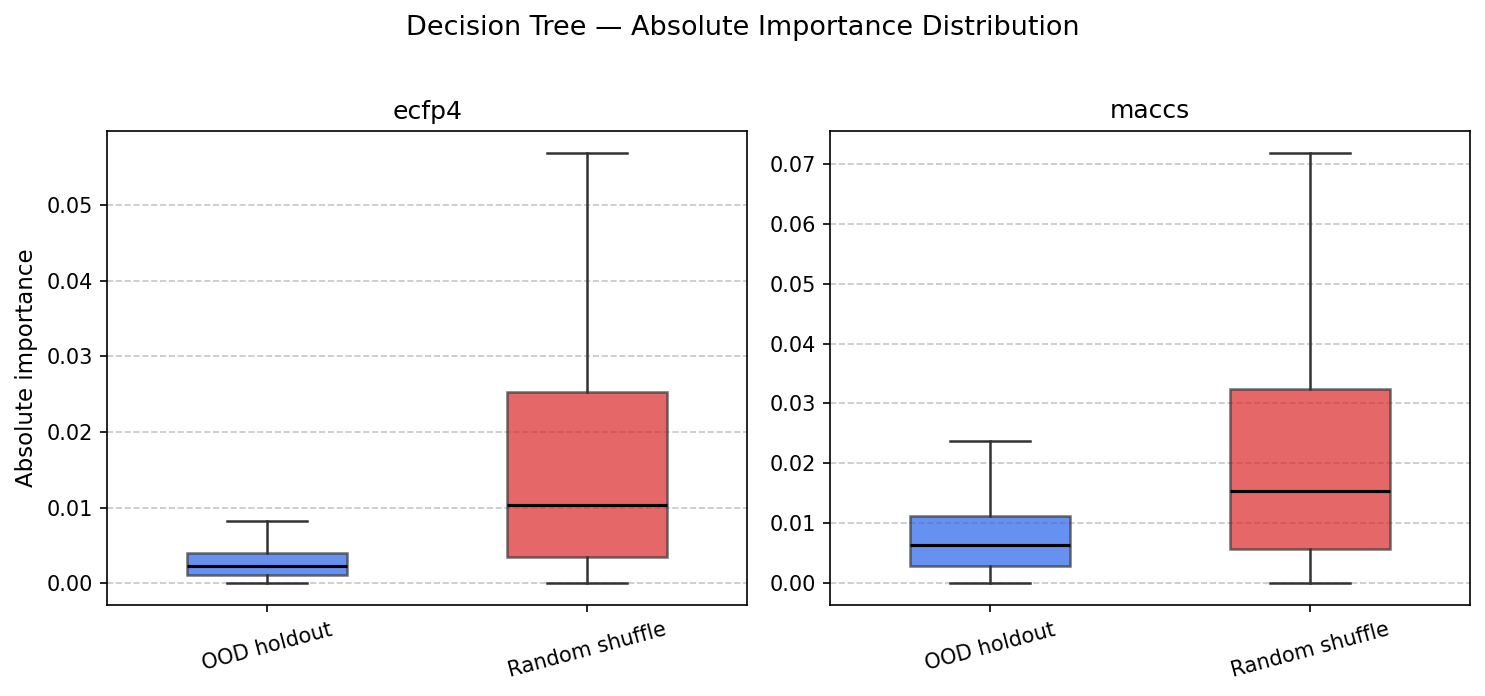

Saved: importance_distribution_logistic_regression.png


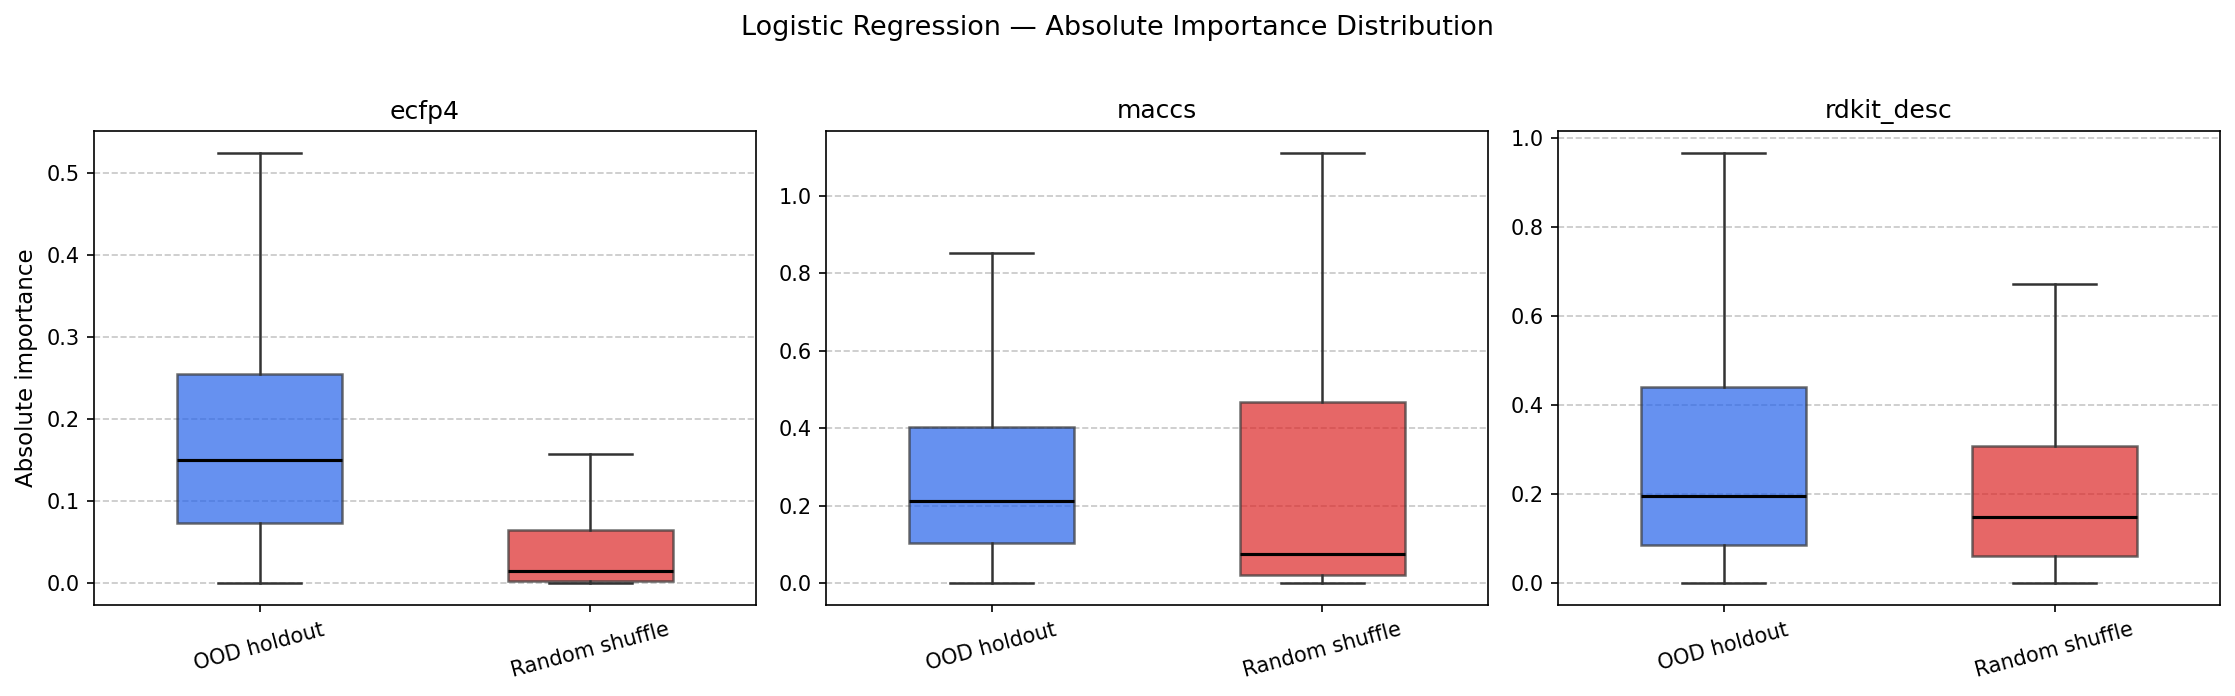

Saved: importance_distribution_svm_linear.png


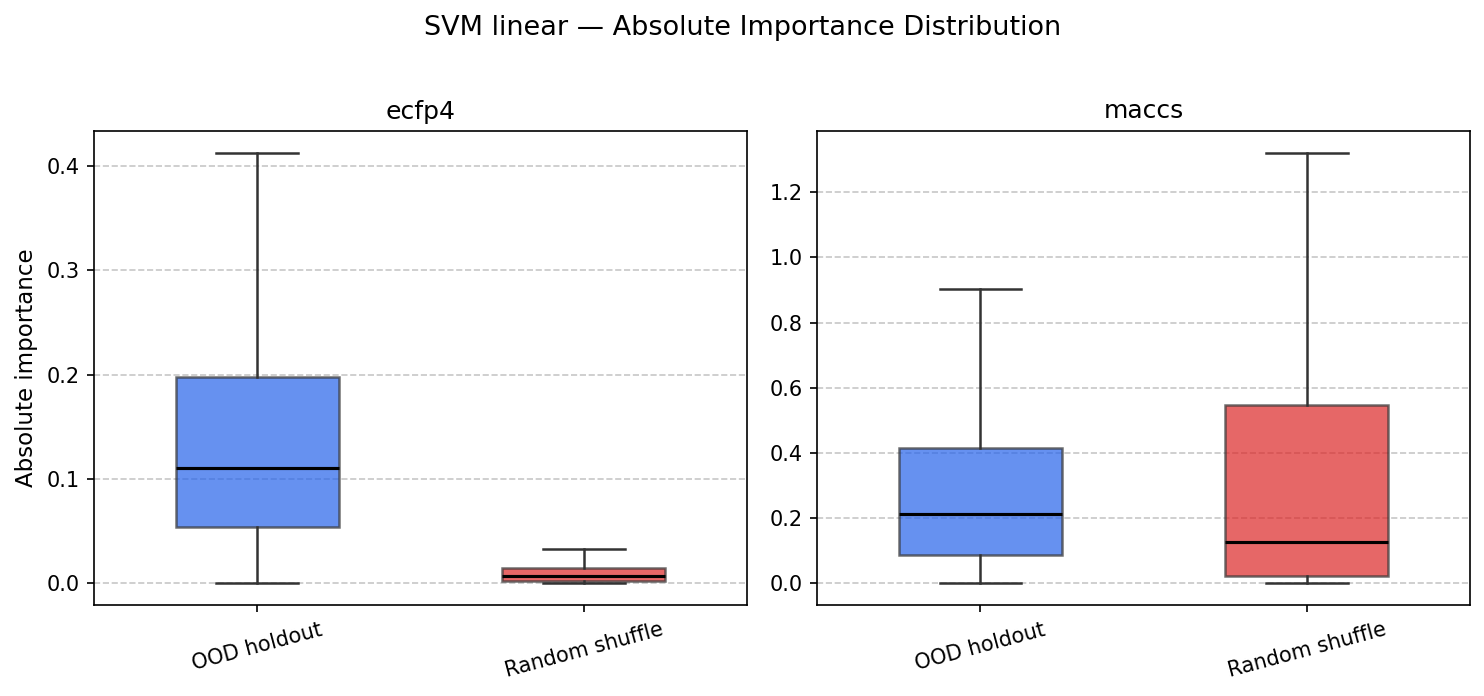

In [2]:
for model in MODELS:
    sub = fi_all[fi_all["model"] == model].copy()
    fps = sorted(sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4.5), sharey=False, squeeze=False)
    fig.suptitle(f"{model} — Absolute Importance Distribution", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_data = sub[sub["fingerprint"] == fp]
 
        fp_data = fp_data[fp_data["abs_importance"] > 0]
 
        box_data = []
        labels = []
        colors = []
 
        for protocol in PROTOCOL_ORDER:
            vals = fp_data.loc[fp_data["protocol"] == protocol, "abs_importance"].values
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(protocol)
                colors.append(PROTOCOL_COLORS[protocol])
 
        if not box_data:
            ax.set_title(f"{fp}\n(no data)")
            continue
 
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True) 
 
        bp = ax.boxplot(
            box_data, 
            tick_labels=labels,       
            patch_artist=True,
            showfliers=False, 
            widths=0.5,
            medianprops=dict(color="black", linewidth=1.5),
            boxprops=dict(linewidth=1.2, color='#333333'),      
            whiskerprops=dict(linewidth=1.2, color='#333333'),  
            capprops=dict(linewidth=1.2, color='#333333')       
        )
        
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7) 
 
        ax.set_title(fp)
        ax.set_ylabel("Absolute importance" if j == 0 else "")
        ax.tick_params(axis="x", rotation=15)
 
    fig.tight_layout()
    fname = FIG_DIR / f"importance_distribution_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname)
    print(f"Saved: {fname.name}")
    plt.show()

# Top-k protocol overlap

/tmp/ipykernel_4114189/1736765025.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, n_fp-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)


Saved: topk_overlap_decision_tree.png


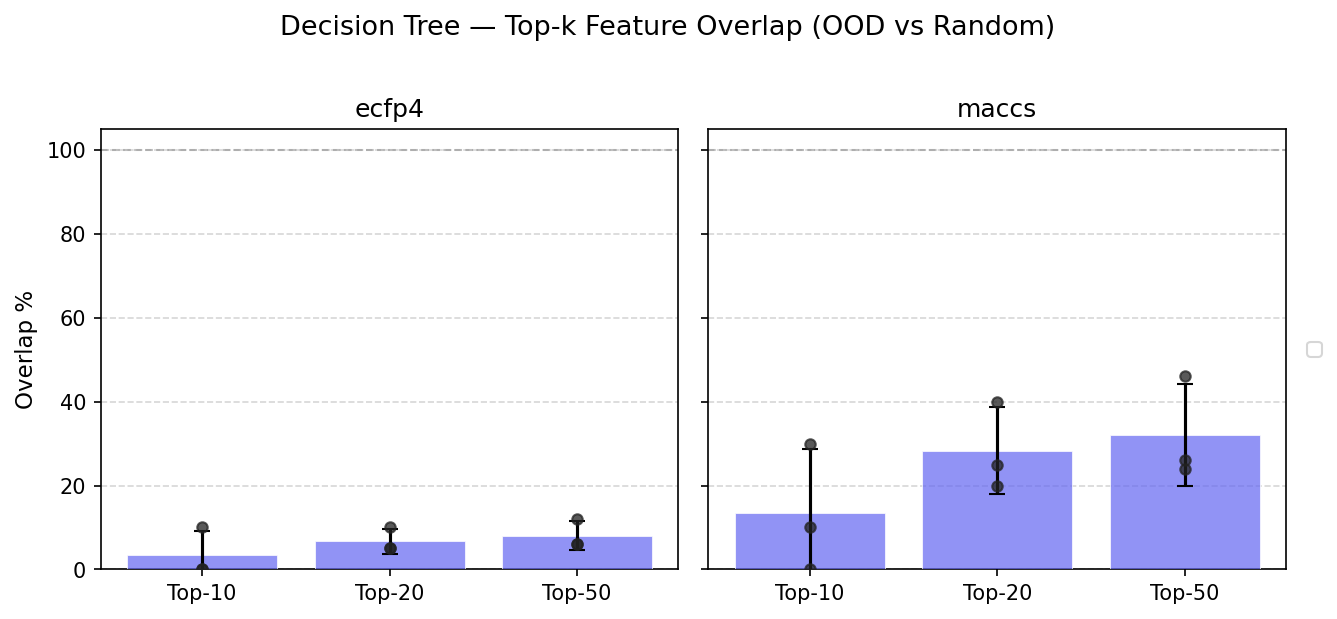

/tmp/ipykernel_4114189/1736765025.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, n_fp-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)


Saved: topk_overlap_logistic_regression.png


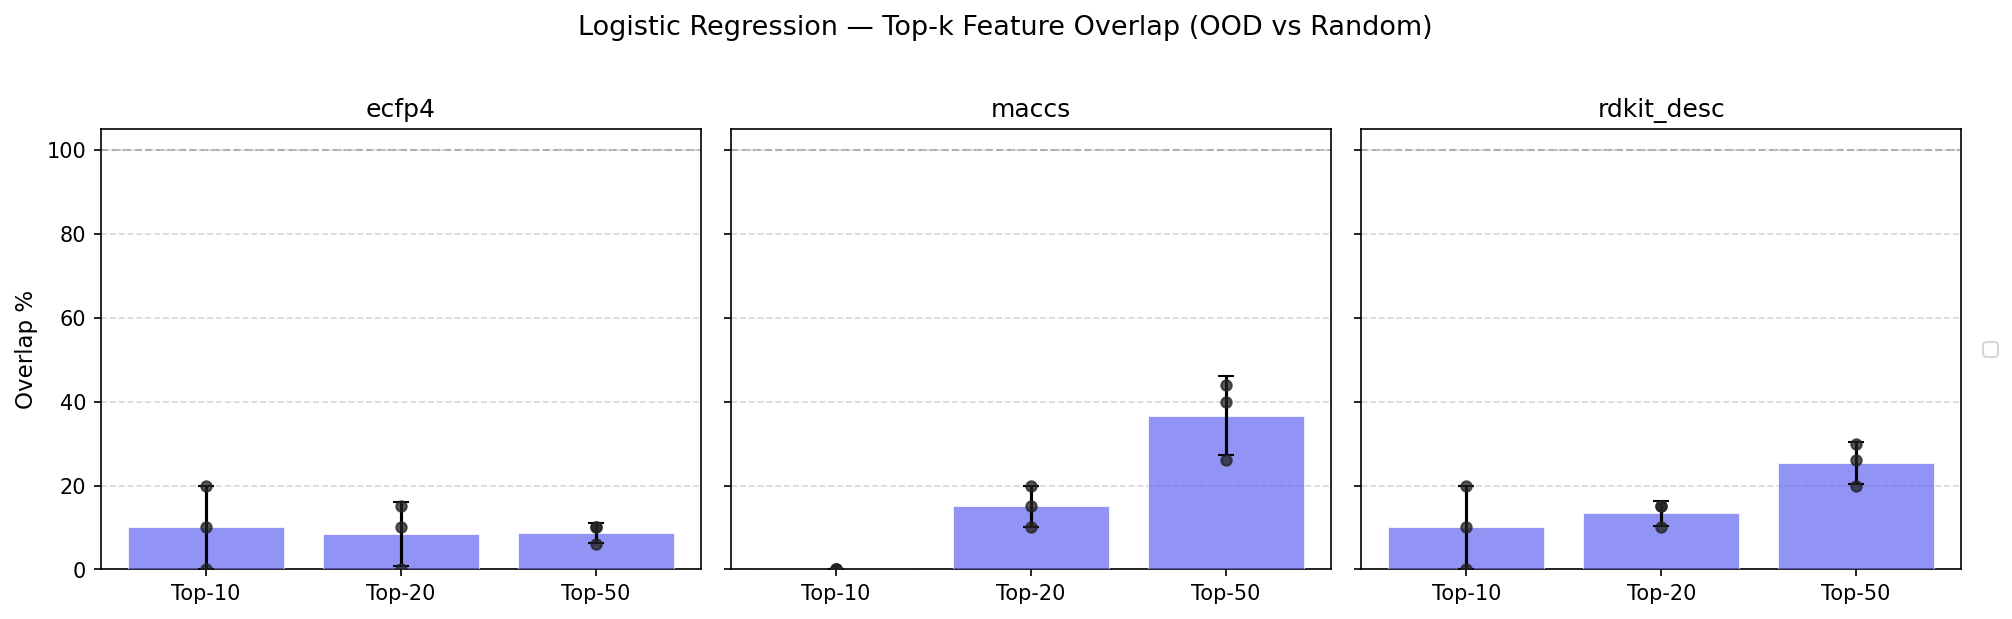

/tmp/ipykernel_4114189/1736765025.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, n_fp-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)


Saved: topk_overlap_svm_linear.png


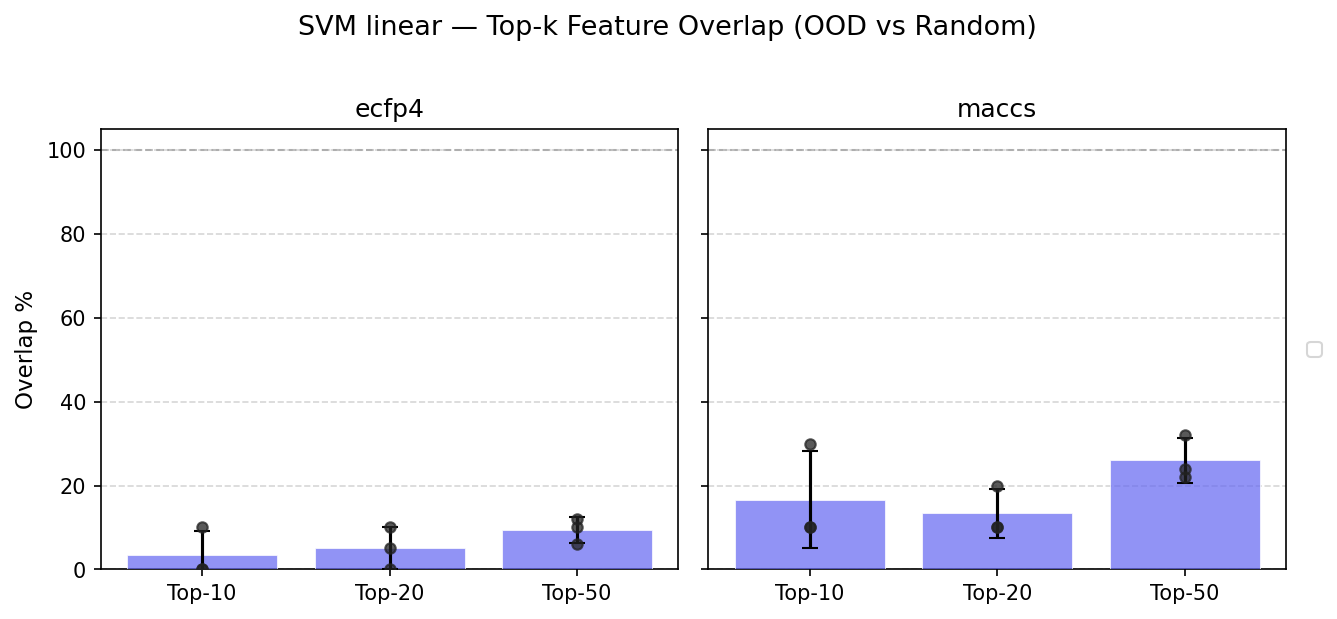

In [3]:
for model in MODELS:
    sub = overlap_protocol[overlap_protocol["model"] == model].copy()
    fps = sorted(sub["fingerprint"].unique())
    ks = sorted(sub["top_k"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(4.5 * n_fp, 4), sharey=True, squeeze=False)
    fig.suptitle(f"{model} — Top-k Feature Overlap (OOD vs Random)", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_sub = sub[sub["fingerprint"] == fp]
 
        mean_overlap = fp_sub.groupby("top_k")["overlap_percent"].agg(["mean", "std"]).reset_index()
 
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
 
        ax.bar(
            range(len(ks)),
            mean_overlap["mean"],
            yerr=mean_overlap["std"],
            color="#6366F1", alpha=0.7, capsize=4,
            edgecolor="white", linewidth=0.5,
            zorder=3  
        )
 
        for fold in [1, 2, 3]:
            fold_sub = fp_sub[fp_sub["fold"] == fold]
            ax.scatter(
                range(len(ks)),
                fold_sub["overlap_percent"].values,
                color="#222222", s=25, zorder=5, alpha=0.75,
                label=f"Fold {fold}" if j == 0 else None,
            )
 
        ax.set_xticks(range(len(ks)))
        ax.set_xticklabels([f"Top-{k}" for k in ks])
        ax.set_title(fp)
        ax.set_ylabel("Overlap %" if j == 0 else "")
        
        ax.set_ylim(0, 105)
        ax.axhline(100, color="gray", linestyle="--", linewidth=1, alpha=0.5, zorder=2)
 
    if n_fp > 0:
        axes[0, n_fp-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
 
    fig.tight_layout()
    fname = FIG_DIR / f"topk_overlap_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname, bbox_inches='tight') 
    print(f"Saved: {fname.name}")
    plt.show()

# Cumulative importance curves

Saved: cumulative_importance_decision_tree.png


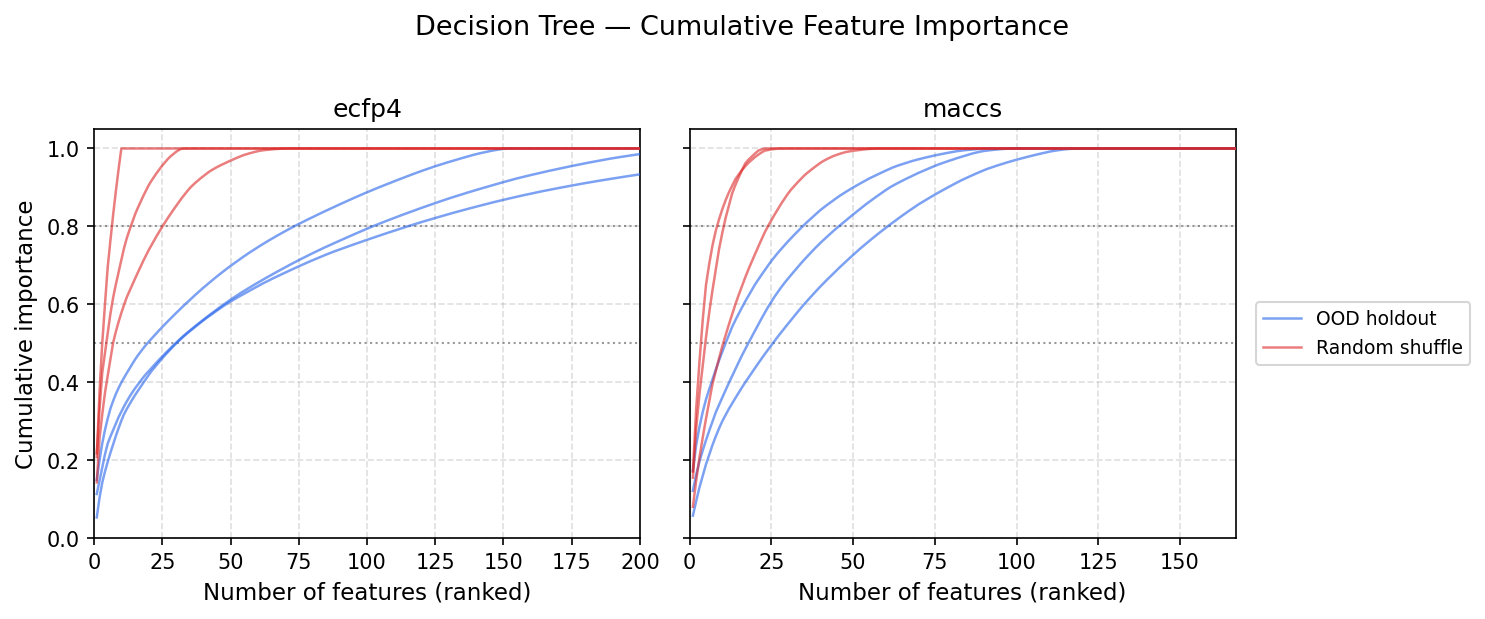

Saved: cumulative_importance_logistic_regression.png


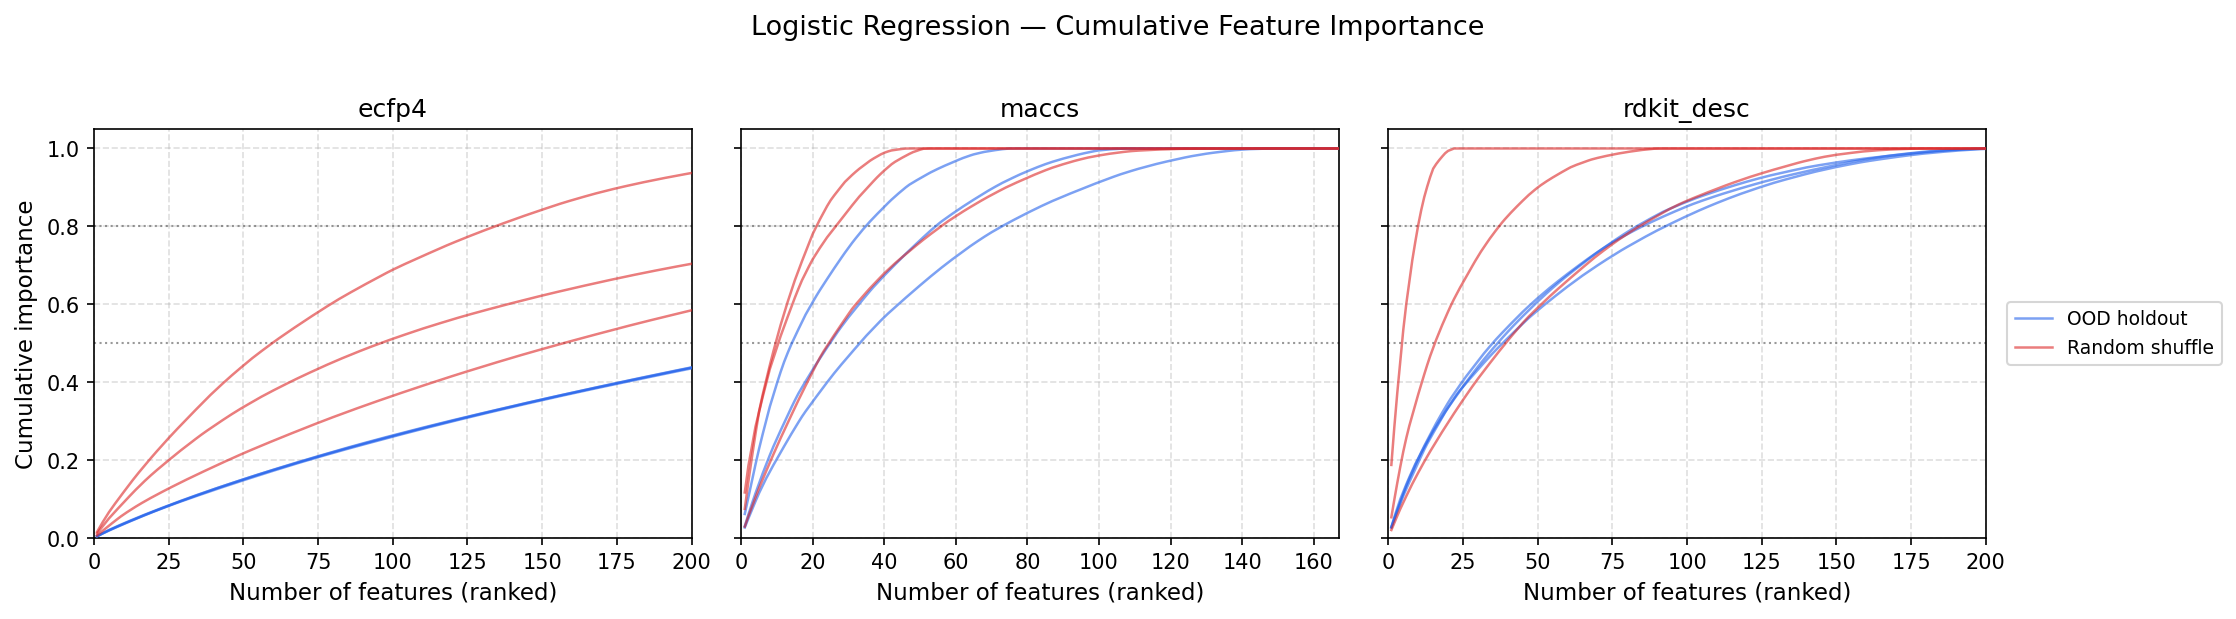

Saved: cumulative_importance_svm_linear.png


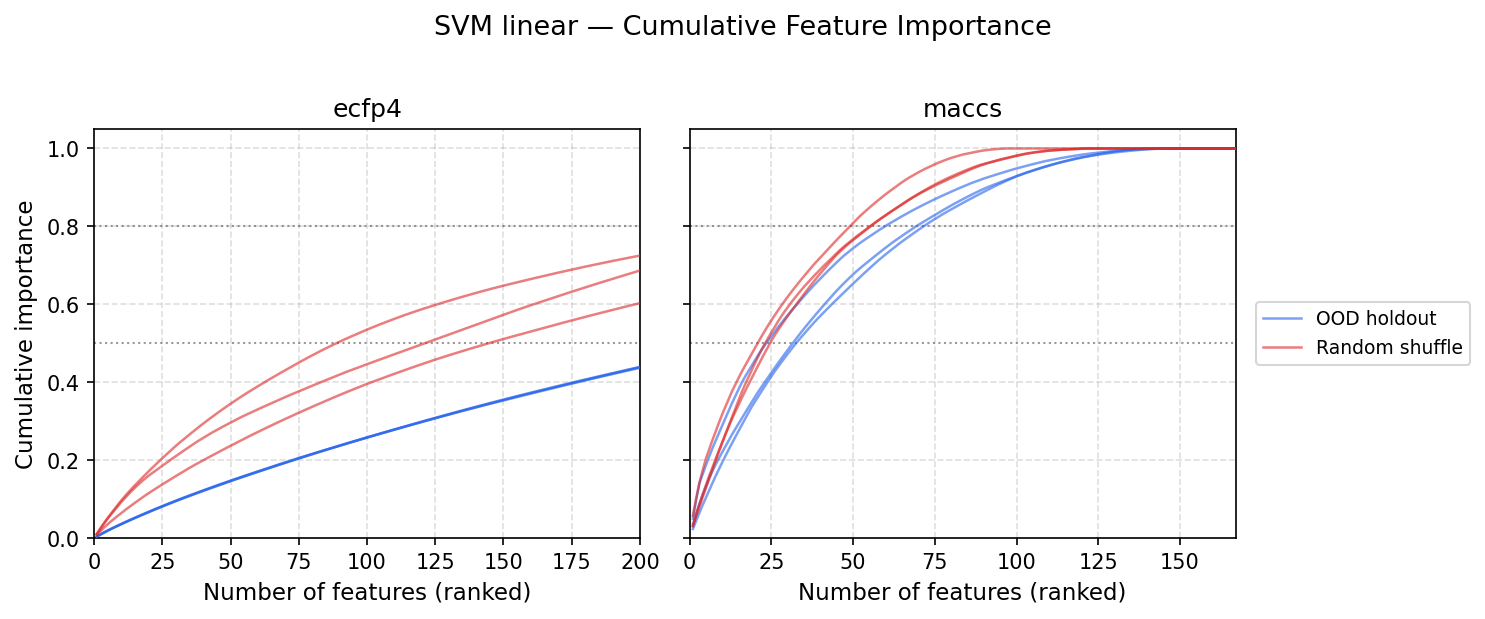

In [4]:
for model in MODELS:
    sub = fi_all[fi_all["model"] == model].copy()
    fps = sorted(sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4), sharey=True, squeeze=False)
    fig.suptitle(f"{model} — Cumulative Feature Importance", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_sub = sub[sub["fingerprint"] == fp]
 
        ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
 
        for protocol in PROTOCOL_ORDER:
            color = PROTOCOL_COLORS[protocol]
 
            for fold in [1, 2, 3]:
                fold_sub = fp_sub[
                    (fp_sub["protocol"] == protocol) & (fp_sub["fold"] == fold)
                ].sort_values("rank")
 
                imp = fold_sub["importance"].fillna(0).values
                cumulative = np.cumsum(imp)
 
                ax.plot(
                    range(1, len(cumulative) + 1), cumulative,
                    color=color, alpha=0.6, linewidth=1.2, 
                    label=f"{protocol}" if fold == 1 else None,
                    zorder=3 
                )
 
        ax.set_title(fp)
        ax.set_xlabel("Number of features (ranked)")
        ax.set_ylabel("Cumulative importance" if j == 0 else "")
        ax.set_ylim(0, 1.05)
        
        ax.axhline(0.8, color="#555555", linestyle=":", linewidth=1, alpha=0.6, zorder=2)
        ax.axhline(0.5, color="#555555", linestyle=":", linewidth=1, alpha=0.6, zorder=2)
 
        n_features = len(fp_sub["feature_idx"].unique())
        ax.set_xlim(0, min(200, n_features))
 
    if n_fp > 0:
        axes[0, n_fp-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
 
    fig.tight_layout()
    fname = FIG_DIR / f"cumulative_importance_{model.lower().replace(' ', '_')}.png"
    fig.savefig(fname, bbox_inches='tight') 
    print(f"Saved: {fname.name}")
    plt.show()

# Decision Tree — Minimum depth distribution

Saved: minimum_depth_decision_tree.png


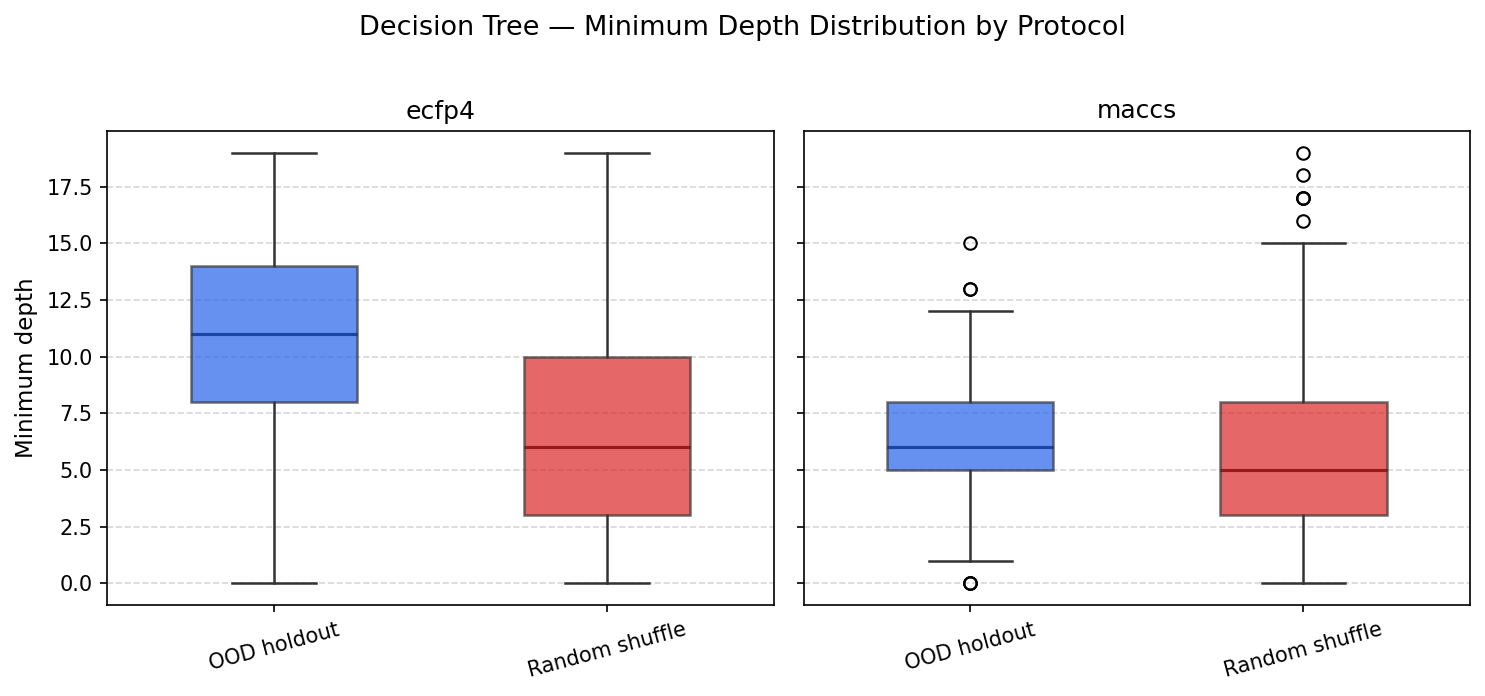

Saved: stability_heatmap_decision_tree_ecfp4.png


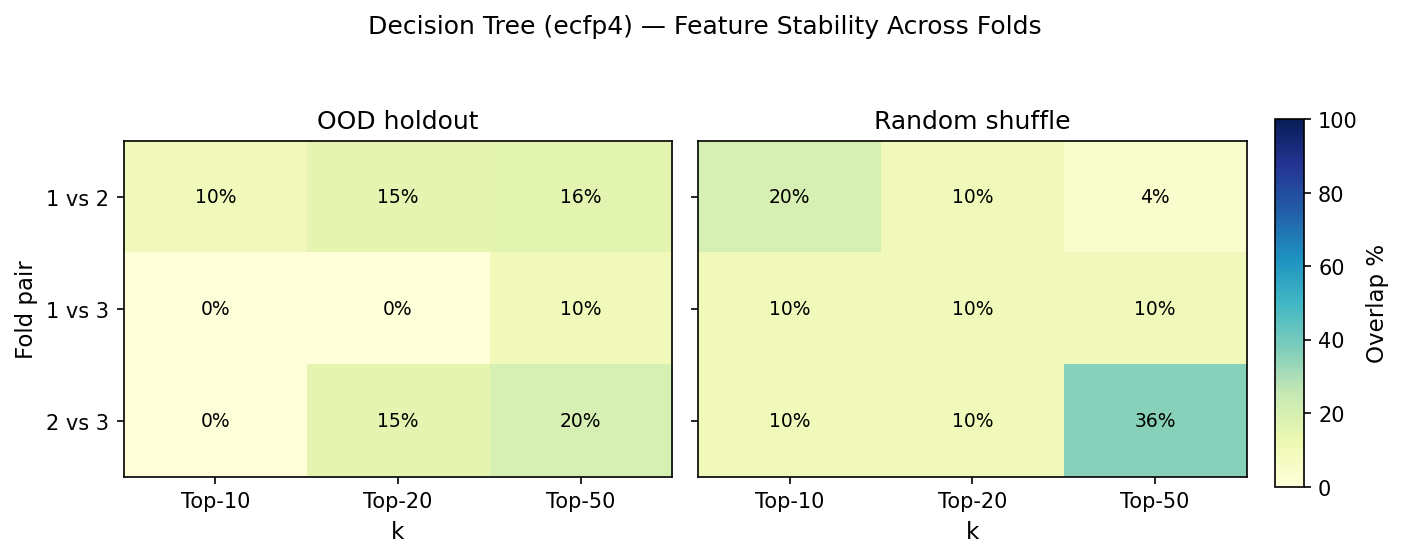

Saved: stability_heatmap_decision_tree_maccs.png


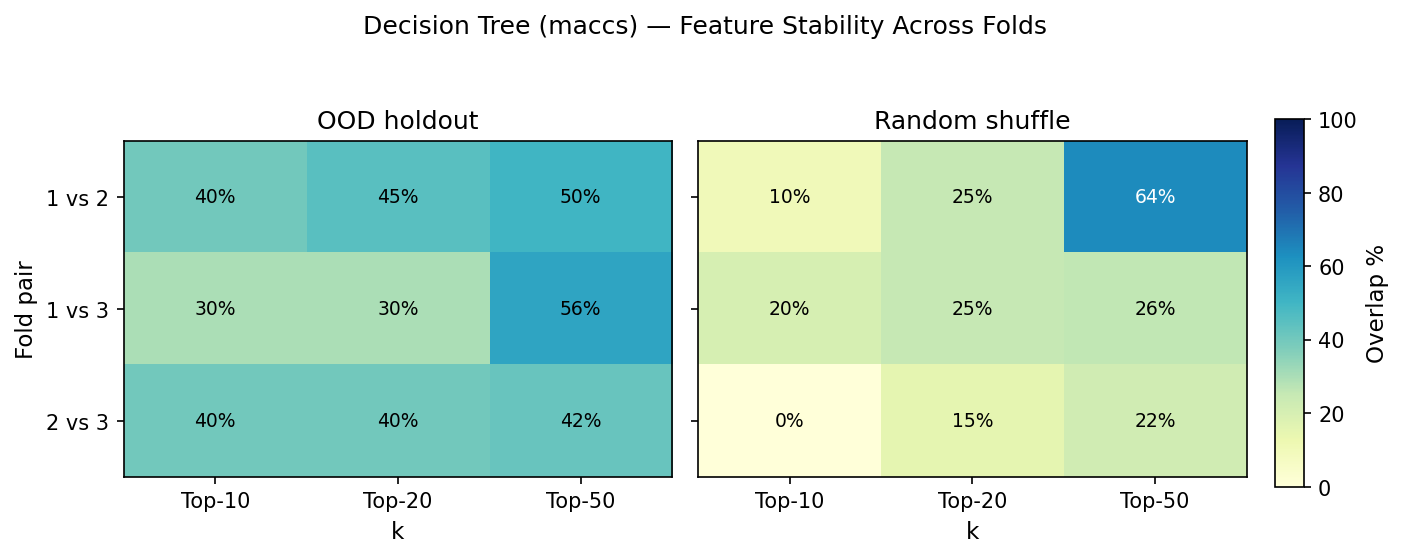

Saved: stability_heatmap_logistic_regression_ecfp4.png


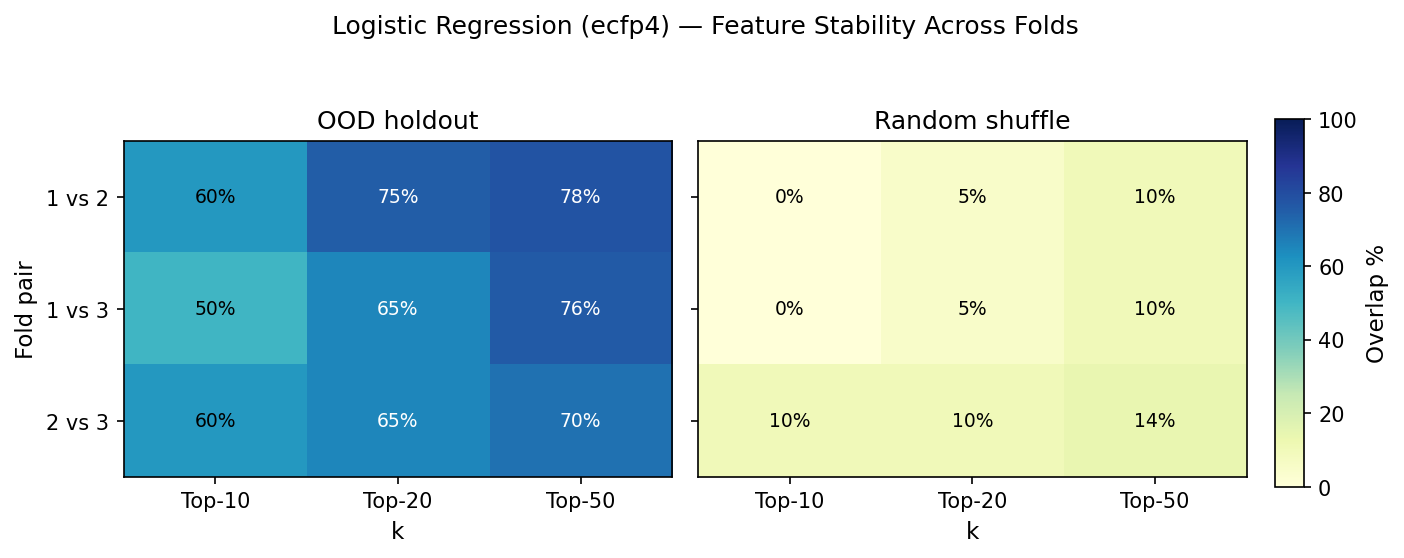

Saved: stability_heatmap_logistic_regression_maccs.png


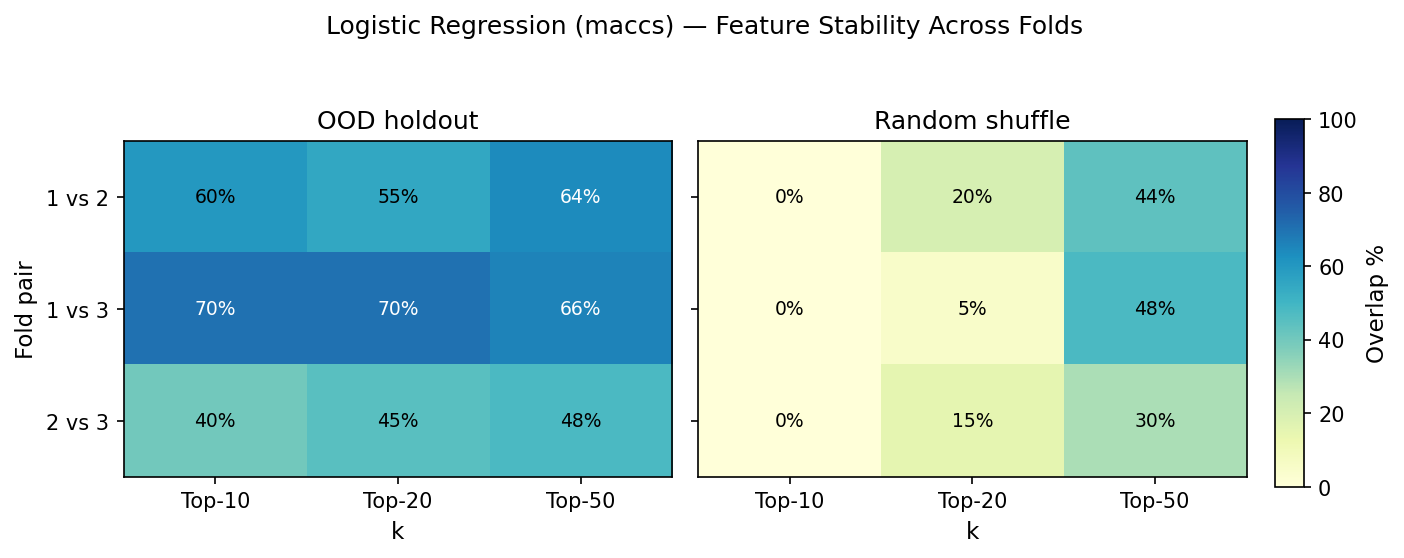

Saved: stability_heatmap_logistic_regression_rdkit_desc.png


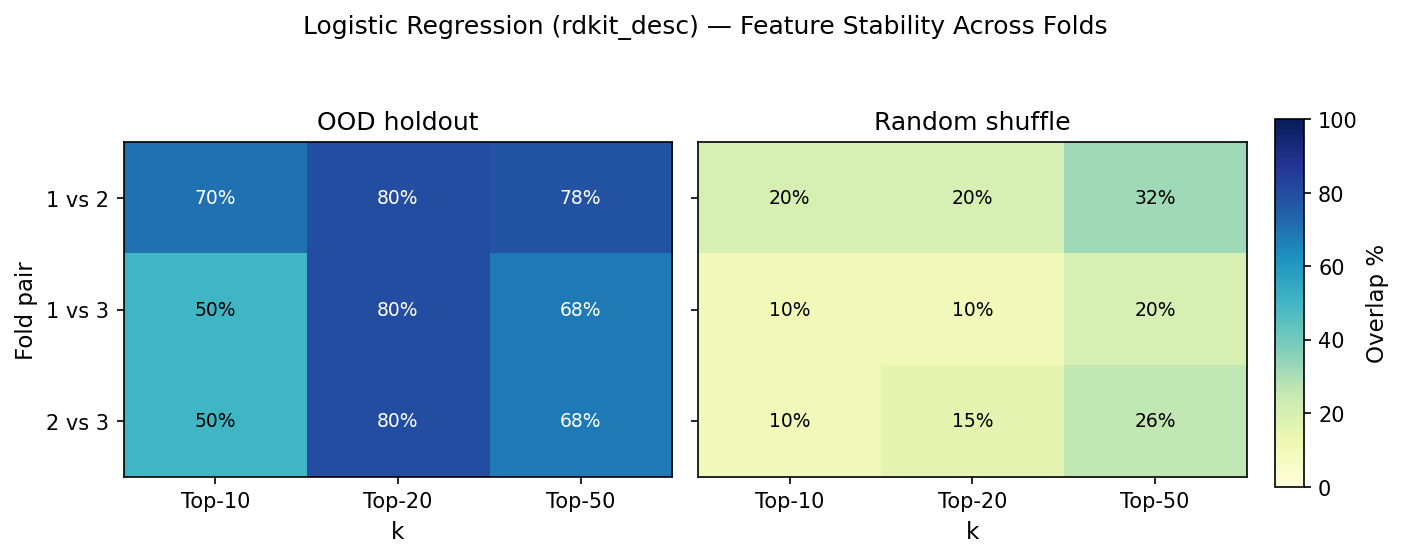

Saved: stability_heatmap_svm_linear_ecfp4.png


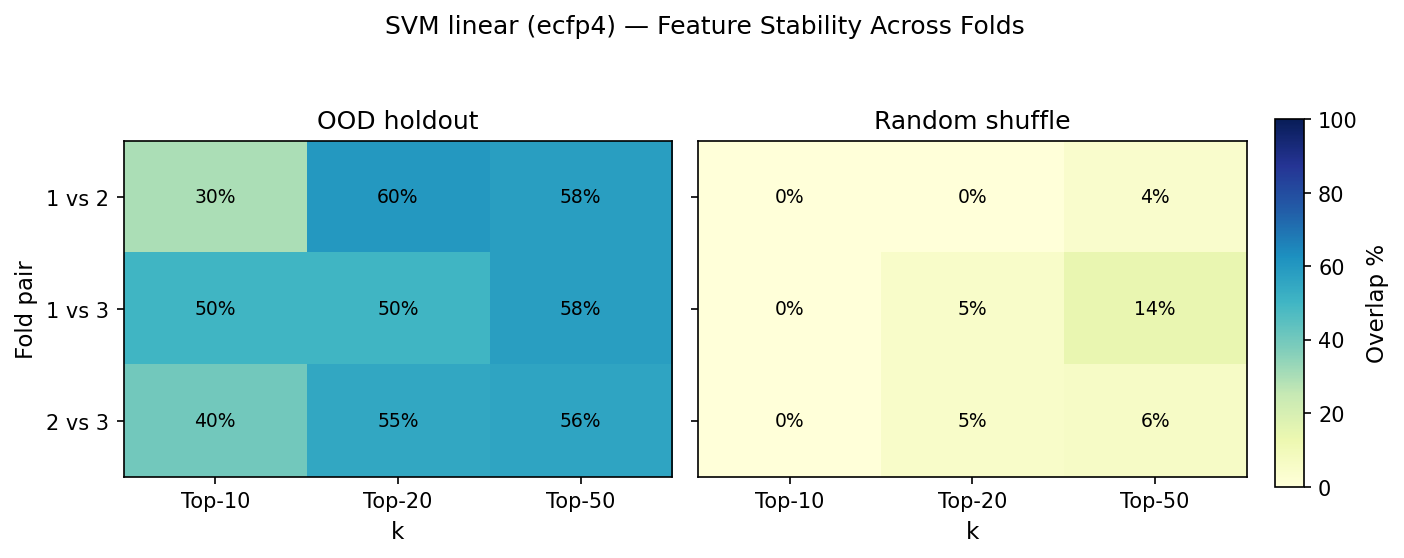

Saved: stability_heatmap_svm_linear_maccs.png


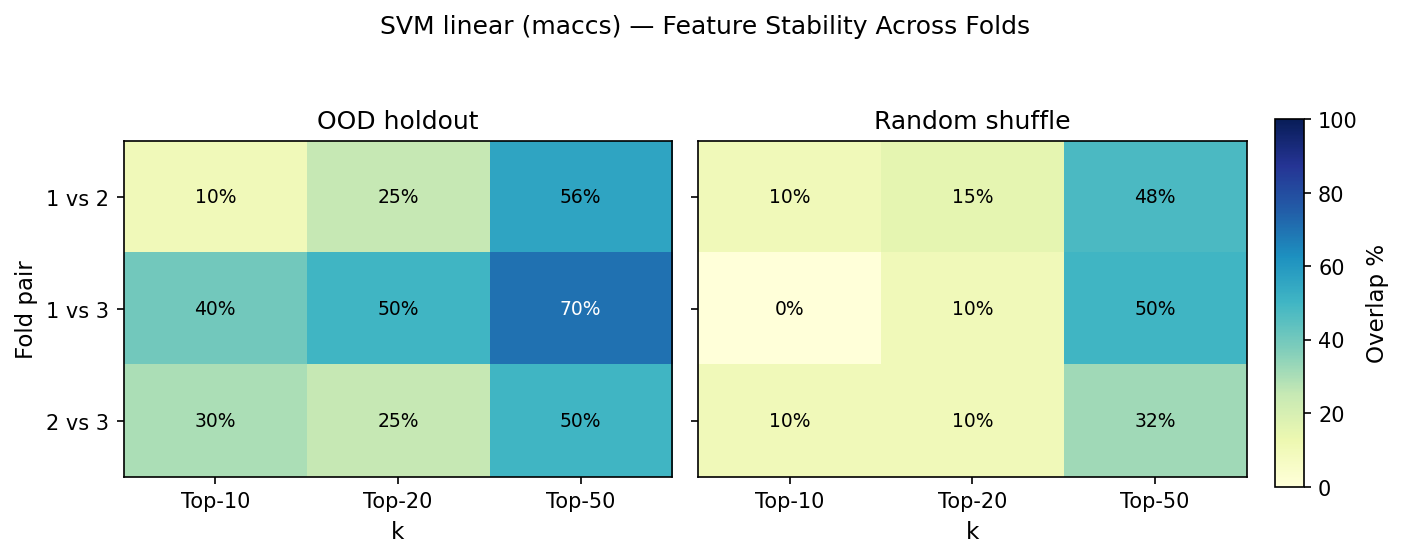

In [5]:

dt_sub = fi_all[
    (fi_all["model"] == "Decision Tree")
    & (fi_all.get("minimum_depth", pd.Series(dtype=float)).notna()
       if "minimum_depth" in fi_all.columns else False)
].copy()
 
if len(dt_sub) > 0 and "minimum_depth" in dt_sub.columns:
    dt_sub = dt_sub.dropna(subset=["minimum_depth"])
    fps = sorted(dt_sub["fingerprint"].unique())
    n_fp = len(fps)
 
    fig, axes = plt.subplots(1, n_fp, figsize=(5 * n_fp, 4.5), sharey=True, squeeze=False)
    fig.suptitle("Decision Tree — Minimum Depth Distribution by Protocol", fontsize=13, y=1.02)
 
    for j, fp in enumerate(fps):
        ax = axes[0, j]
        fp_data = dt_sub[dt_sub["fingerprint"] == fp]
 
        box_data = []
        labels = []
        colors = []
 
        for protocol in PROTOCOL_ORDER:
            vals = fp_data.loc[fp_data["protocol"] == protocol, "minimum_depth"].values
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(protocol)
                colors.append(PROTOCOL_COLORS[protocol])
 
        ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

        if box_data:
            bp = ax.boxplot(
                box_data, 
                tick_labels=labels,
                patch_artist=True,
                showfliers=True, 
                widths=0.5,
                medianprops=dict(color="black", linewidth=1.5),
                boxprops=dict(linewidth=1.2, color='#333333', zorder=3),
                whiskerprops=dict(linewidth=1.2, color='#333333'),
                capprops=dict(linewidth=1.2, color='#333333')
            )
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
 
        ax.set_title(fp)
        ax.set_ylabel("Minimum depth" if j == 0 else "")
        ax.invert_yaxis()  
        ax.tick_params(axis="x", rotation=15)
 
    fig.tight_layout()
    fname = FIG_DIR / "minimum_depth_decision_tree.png"
    fig.savefig(fname)
    print(f"Saved: {fname.name}")
    plt.show()
else:
    print("No minimum_depth data available for Decision Tree. Skipping.")


for model in MODELS:
    model_stab = stability[stability["model"] == model]
    fps = sorted(model_stab["fingerprint"].unique())
 
    for fp in fps:
        fp_stab = model_stab[model_stab["fingerprint"] == fp]
 
        if len(fp_stab) == 0:
            continue
 
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5), sharey=True)
        fig.suptitle(f"{model} ({fp}) — Feature Stability Across Folds", fontsize=12, y=1.05)
 
        im = None 

        for i, protocol in enumerate(PROTOCOL_ORDER):
            ax = axes[i]
            p_sub = fp_stab[fp_stab["protocol"] == protocol]
 
            if len(p_sub) == 0:
                ax.set_title(f"{protocol}\n(no data)")
                continue
 
            pivot = p_sub.pivot_table(
                index="fold_pair", columns="top_k", values="overlap_percent",
            )
 
            im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=0, vmax=100, aspect="auto")
 
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"Top-{k}" for k in pivot.columns])
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(protocol)
            ax.set_xlabel("k")
            if i == 0:
                ax.set_ylabel("Fold pair")
 
            for row_idx in range(len(pivot.index)):
                for col_idx in range(len(pivot.columns)):
                    val = pivot.values[row_idx, col_idx]
                    text_color = "white" if val > 60 else "black"
                    ax.text(col_idx, row_idx, f"{val:.0f}%",
                            ha="center", va="center", fontsize=9, color=text_color)
 
        fig.tight_layout()
        
        if im is not None:
            fig.subplots_adjust(right=0.88) 
            cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7]) 
            fig.colorbar(im, cax=cbar_ax, label="Overlap %")

        fname = FIG_DIR / f"stability_heatmap_{model.lower().replace(' ', '_')}_{fp}.png"
        fig.savefig(fname, bbox_inches='tight')
        print(f"Saved: {fname.name}")
        plt.show()

# Local feature contributions

Saved: local_logistic_regression_ecfp4_fold1_both_correct.png


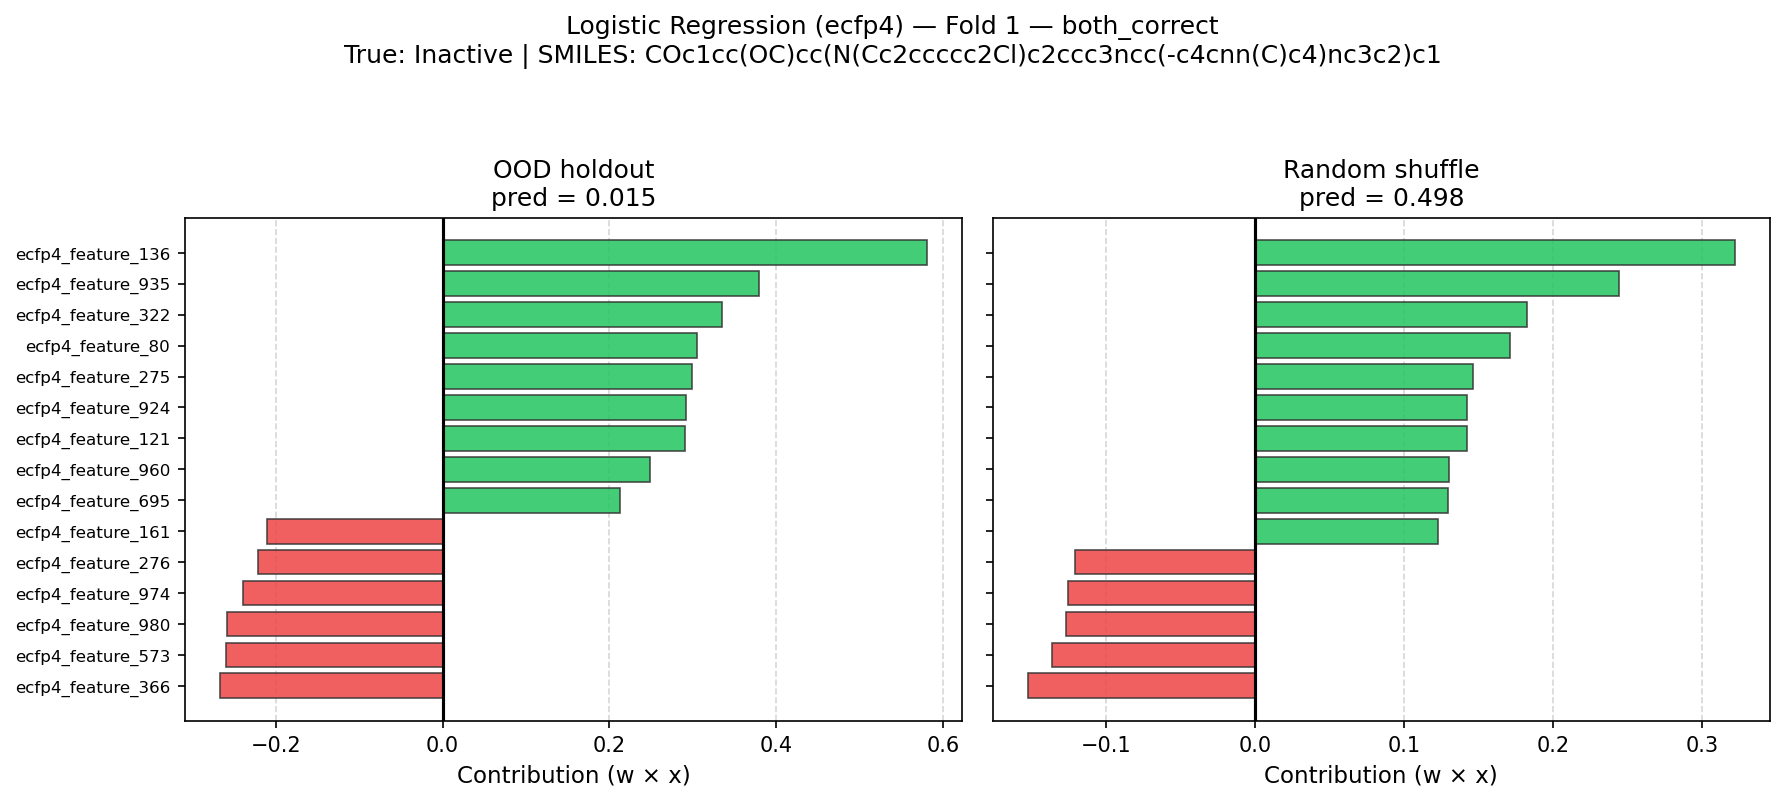

Saved: local_logistic_regression_ecfp4_fold1_both_wrong.png


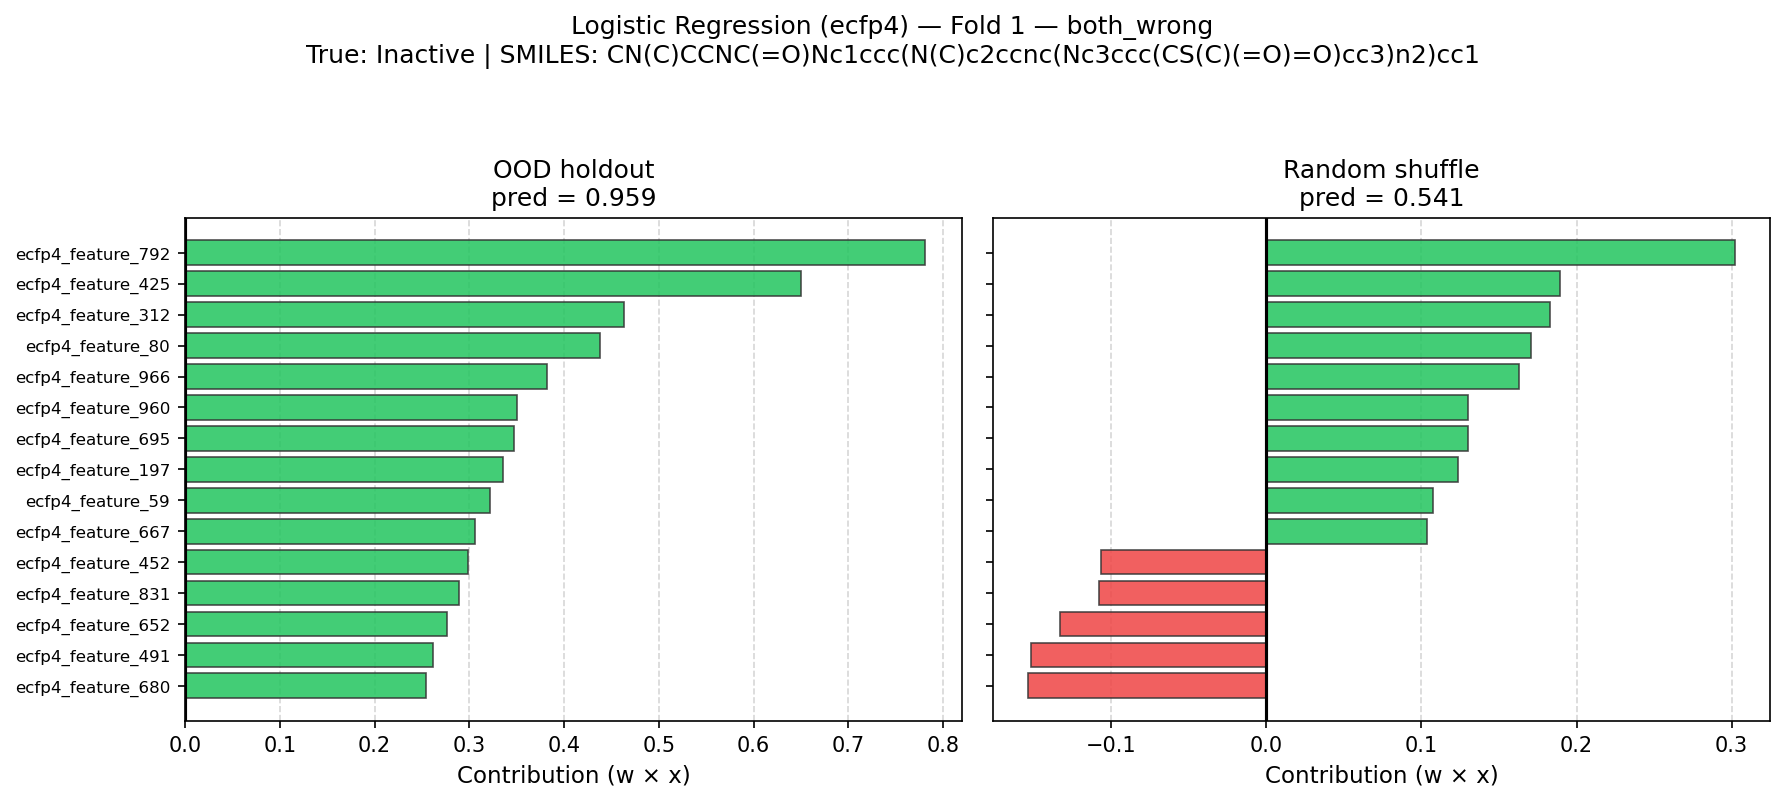

Saved: local_logistic_regression_ecfp4_fold1_ood_correct_random_wrong.png


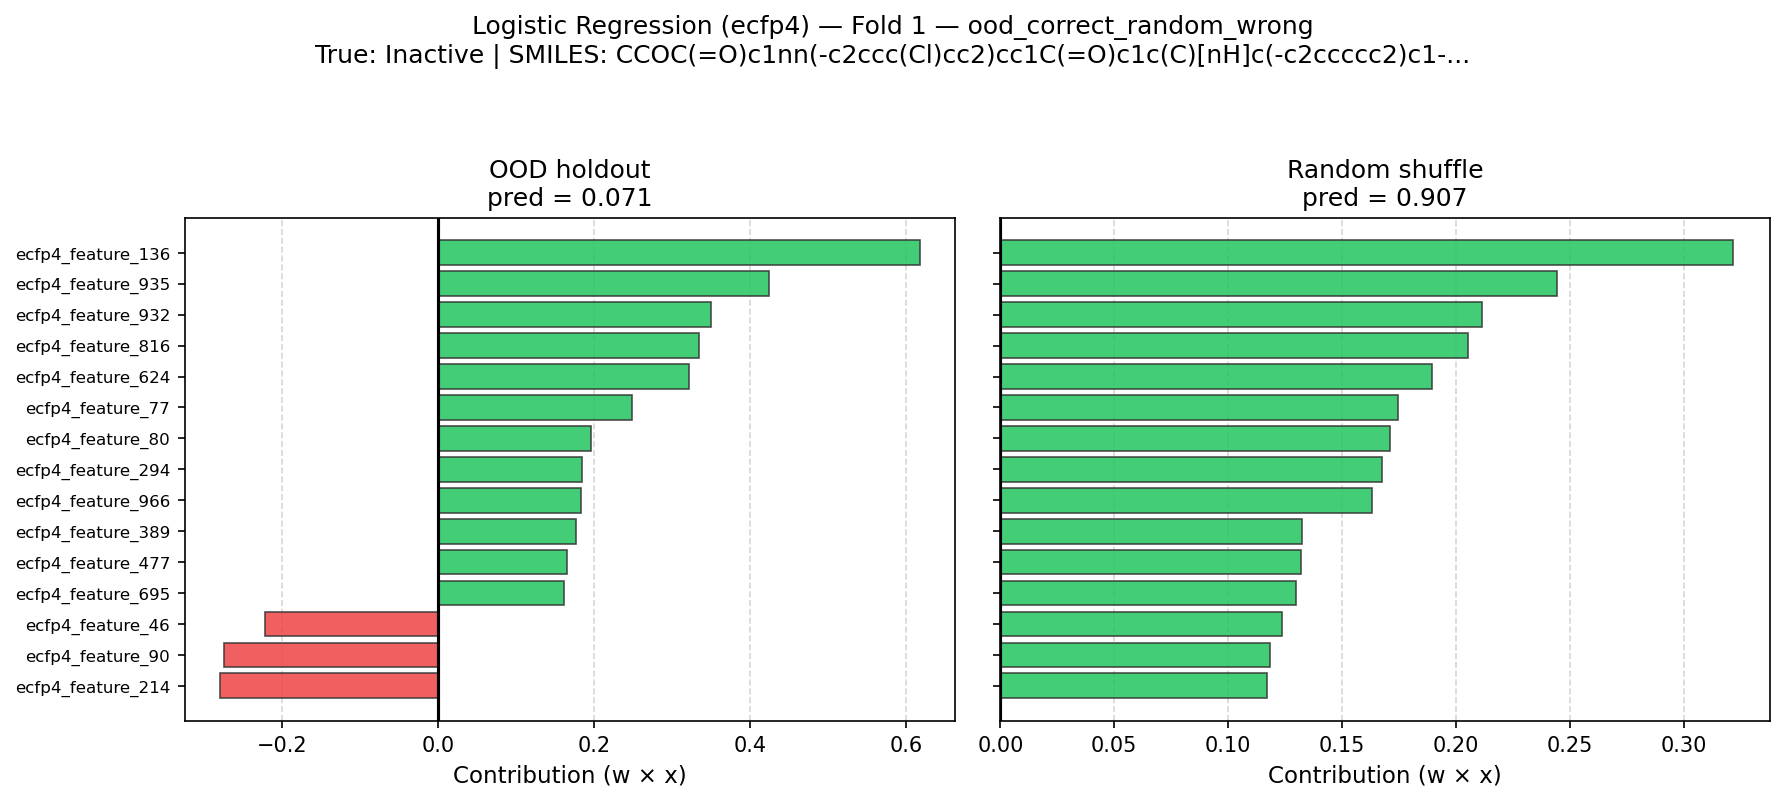

Saved: local_logistic_regression_ecfp4_fold1_ood_wrong_random_correct.png


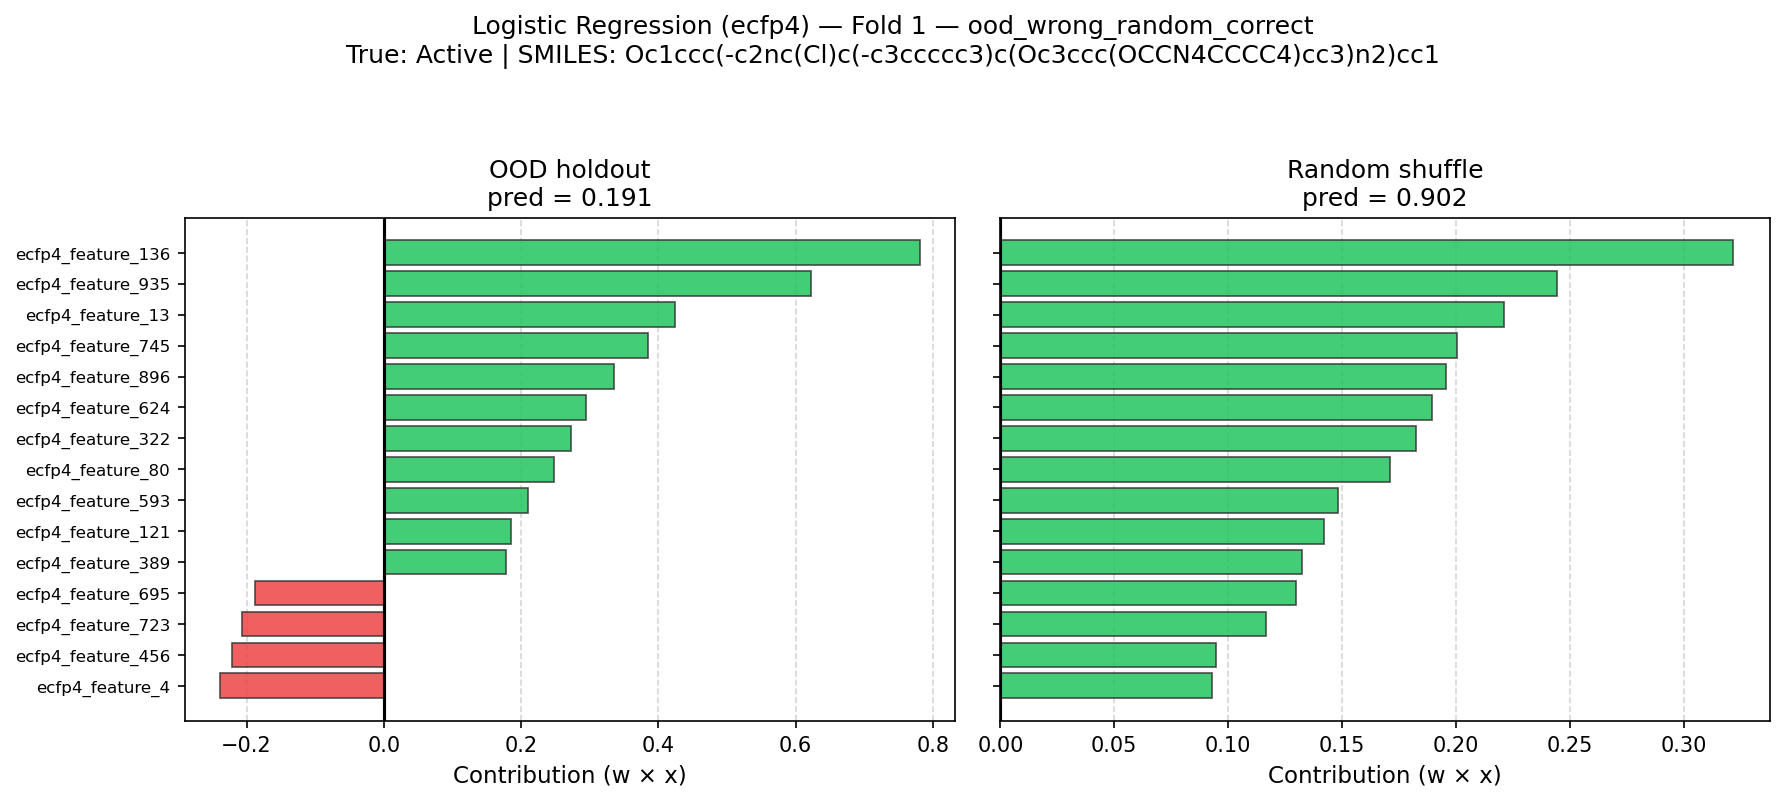

Saved: local_logistic_regression_ecfp4_fold2_both_correct.png


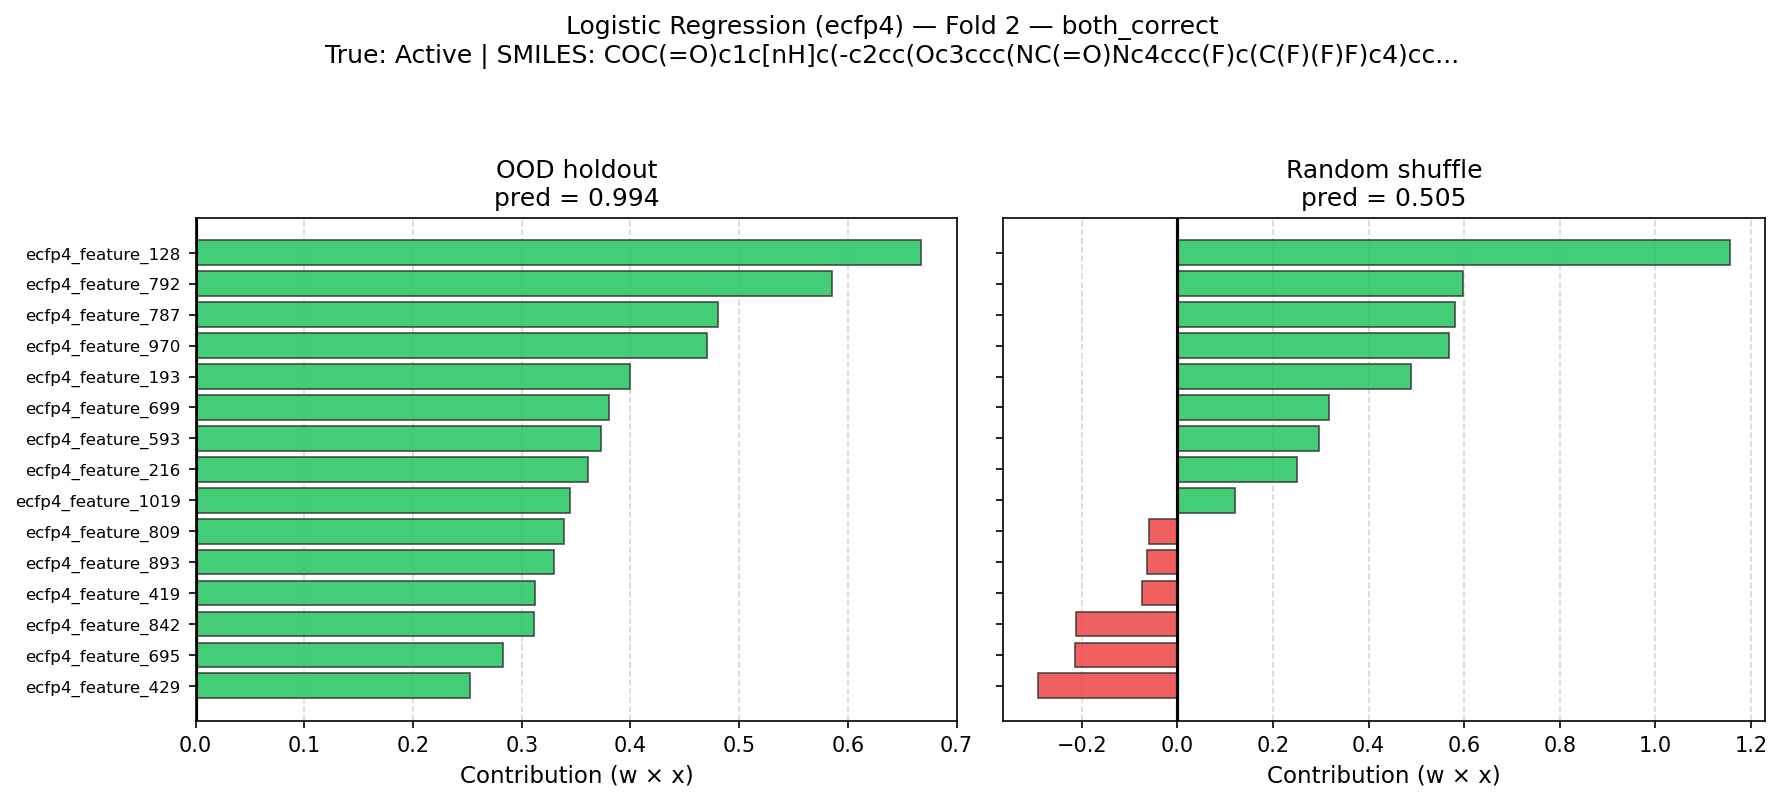

Saved: local_logistic_regression_ecfp4_fold2_both_wrong.png


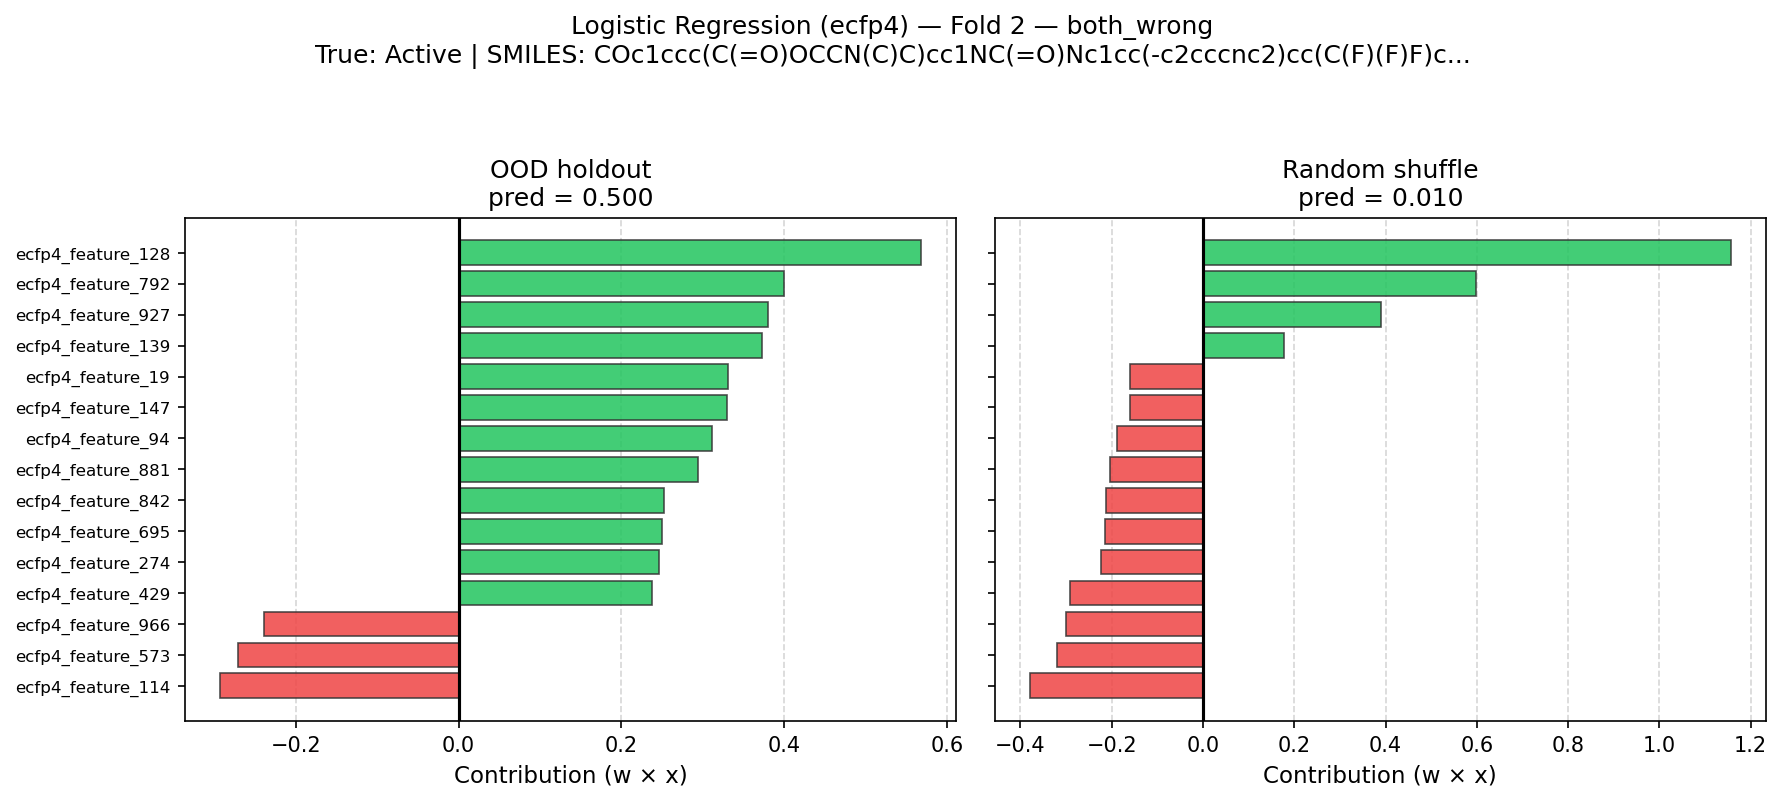

Saved: local_logistic_regression_ecfp4_fold2_ood_correct_random_wrong.png


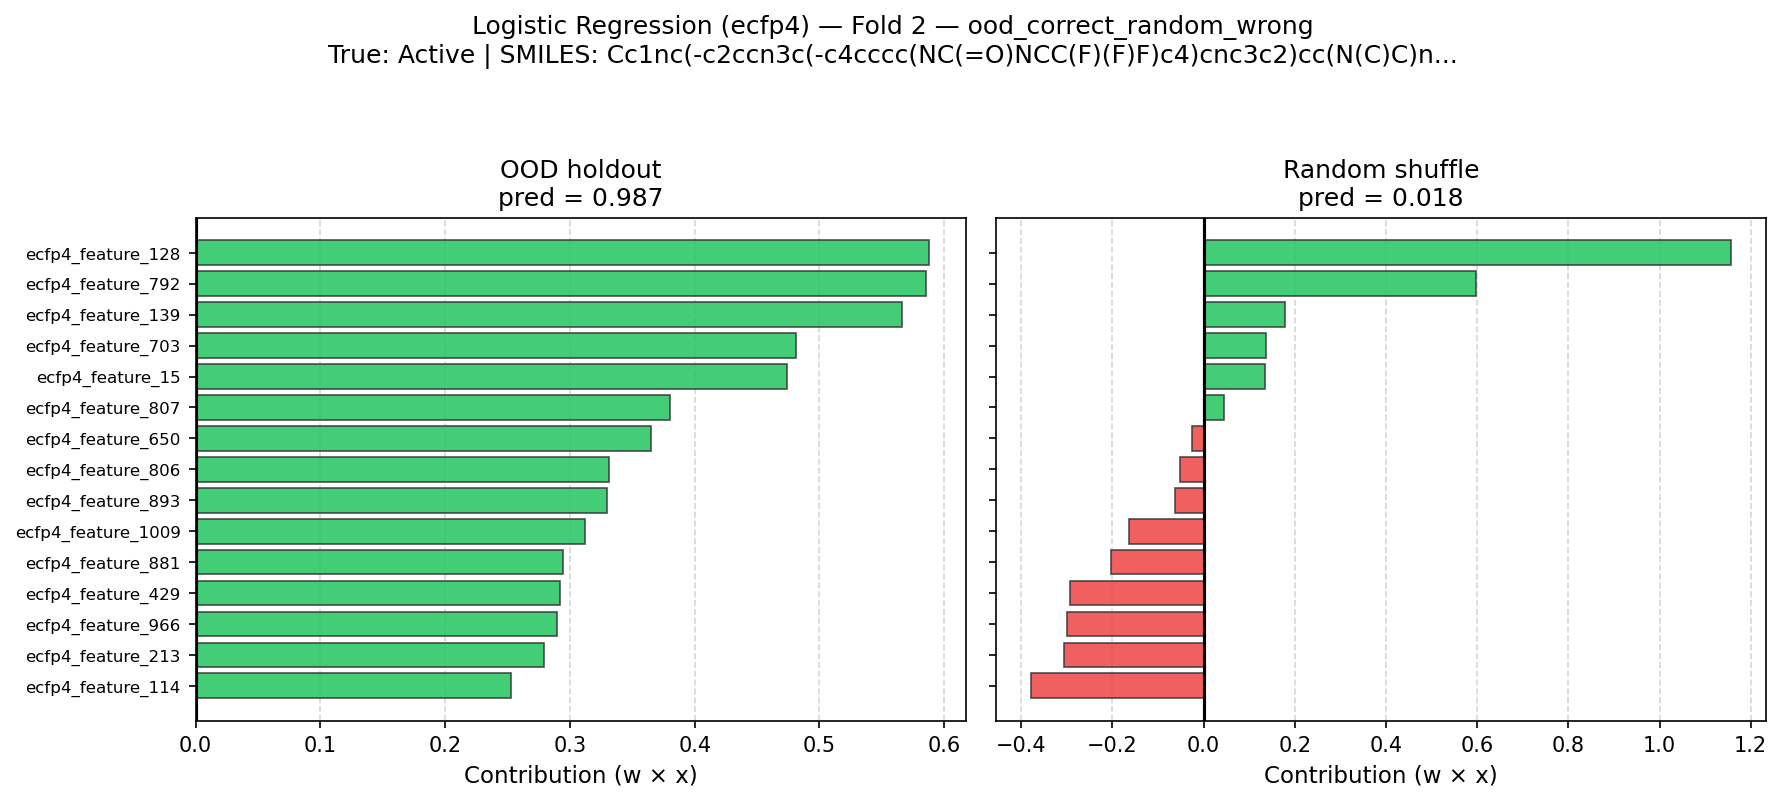

Saved: local_logistic_regression_ecfp4_fold2_ood_wrong_random_correct.png


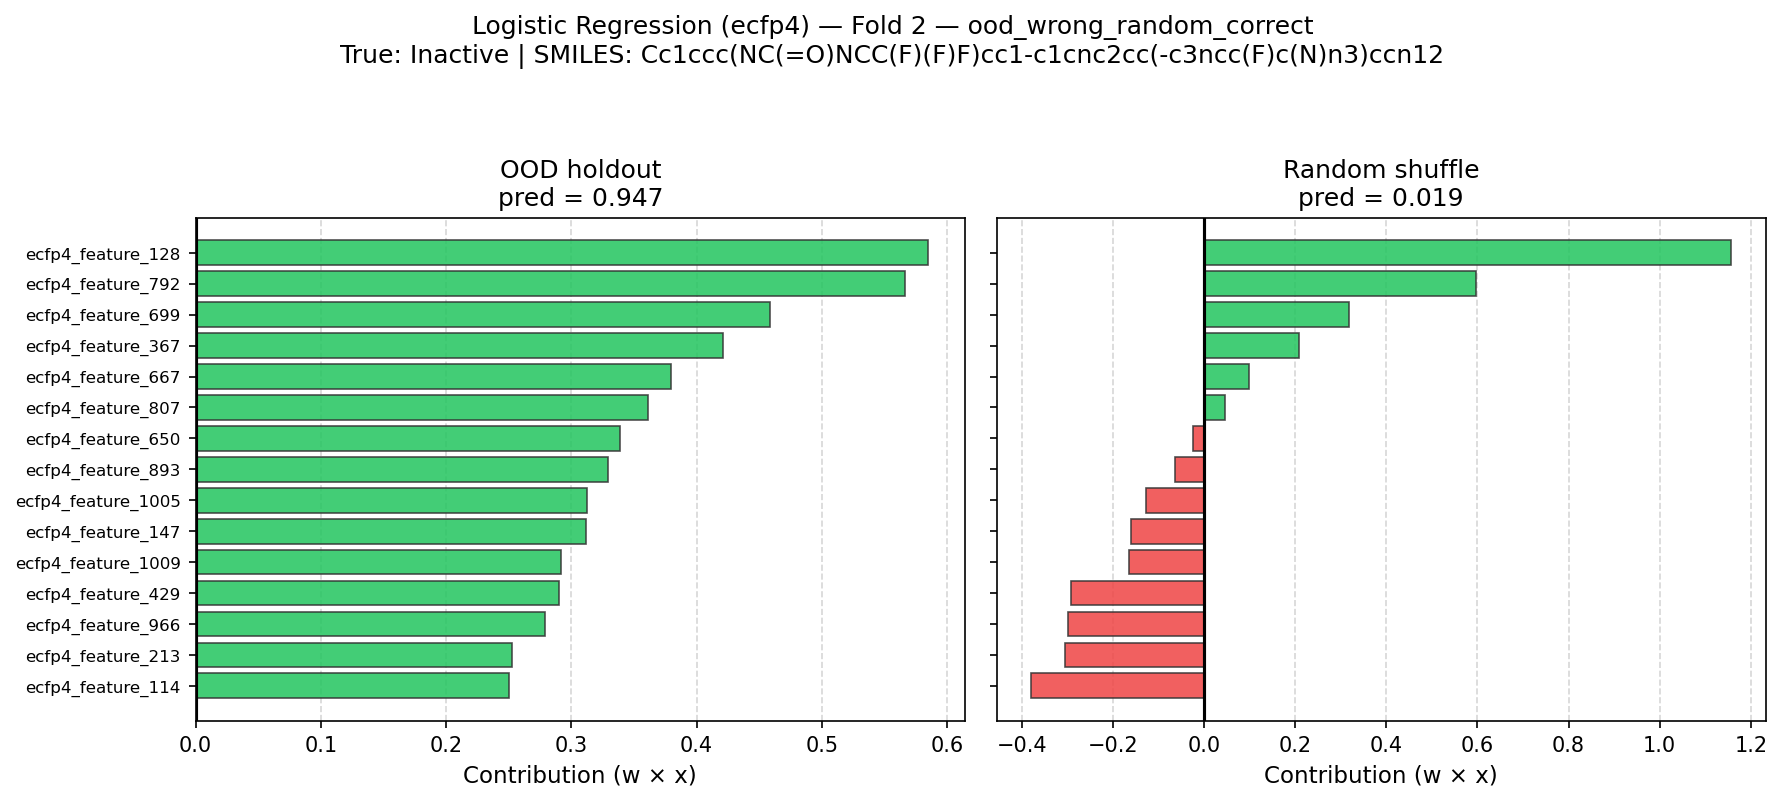

In [6]:
if len(local_contributions) == 0:
    print("No local contributions available. Skipping.")
else:
    group_keys = local_contributions.groupby(
        ["model", "fingerprint", "fold", "smiles"]
    ).ngroups
 
    unique_molecules = (
        local_contributions
        .drop_duplicates(subset=["model", "fingerprint", "fold", "smiles", "category"])
        .sort_values(["model", "fingerprint", "fold", "category"])
    )
 
    shown = set()
 
    for _, mol_row in unique_molecules.iterrows():
        mol_key = (mol_row["model"], mol_row["fingerprint"], mol_row["smiles"])
        if mol_key in shown:
            continue
 
        model = mol_row["model"]
        fp = mol_row["fingerprint"]
        fold = mol_row["fold"]
        smiles = mol_row["smiles"]
        category = mol_row["category"]
        true_label = mol_row["true_label"]
 
        mol_data = local_contributions[
            (local_contributions["model"] == model)
            & (local_contributions["fingerprint"] == fp)
            & (local_contributions["fold"] == fold)
            & (local_contributions["smiles"] == smiles)
        ]
 
        protocols_available = mol_data["protocol"].unique()
        if len(protocols_available) < 2:
            continue
 
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        fig.suptitle(
            f"{model} ({fp}) — Fold {fold} — {category}\n"
            f"True: {'Active' if true_label else 'Inactive'} | "
            f"SMILES: {smiles[:60]}{'...' if len(smiles) > 60 else ''}",
            fontsize=12, y=1.06, 
        )
 
        for i, protocol in enumerate(PROTOCOL_ORDER):
            ax = axes[i]
            p_data = mol_data[mol_data["protocol"] == protocol].copy()
 
            if len(p_data) == 0:
                ax.set_title(f"{protocol}\n(no data)")
                continue
 
            p_data = p_data.sort_values("contribution", ascending=True).tail(15)
 
            colors = [
                "#22C55E" if c > 0 else "#EF4444" if c < 0 else "#9CA3AF"
                for c in p_data["contribution"]
            ]
            
            ax.xaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
            ax.set_axisbelow(True)

            ax.barh(
                range(len(p_data)),
                p_data["contribution"].values,
                color=colors, 
                edgecolor="#333333", 
                linewidth=0.8,       
                alpha=0.85,          
                zorder=3
            )
 
            ax.set_yticks(range(len(p_data)))
            ax.set_yticklabels(p_data["feature_name"].values, fontsize=8)
            
            ax.axvline(0, color="black", linewidth=1.5, zorder=4)
            ax.set_xlabel("Contribution (w × x)")
 
            pred_val = mol_row["pred_ood"] if protocol == "OOD holdout" else mol_row["pred_random"]
            ax.set_title(f"{protocol}\npred = {pred_val:.3f}")
 
        fig.tight_layout()
        fname = FIG_DIR / f"local_{model.lower().replace(' ', '_')}_{fp}_fold{fold}_{category}.png"
        fig.savefig(fname, bbox_inches='tight')
        print(f"Saved: {fname.name}")
        plt.show()
 
        shown.add(mol_key)
 
        if len(shown) >= 8:
            break